In [7]:
import numpy as np
import scipy as sp 
from scipy import constants
import matplotlib.pyplot as plt
import sympy as sym 
from sympy import I, exp, init_printing 
from fractions import Fraction 
from matplotlib.pyplot import figure
init_printing()

In [8]:
# Transfer function 

def interference(amp, phs):
    return (1 + amp**2 - 2*amp*np.cos(phs))

def sweep_interference(amp, phs):
    no_dp = len(amp)
    
    arr = np.ones((no_dp, no_dp))
        
    for i in range(no_dp):
        arr[i] = 1 + amp[i]**2 - 2*amp[i]*np.cos(phs*np.pi/180)
    
    return arr
    
    
def get_interference_data(amp_mismatch, phs_mismatch):
    if amp_mismatch.size == phs_mismatch.size:
        return (1 + amp_mismatch**2 - 2*amp_mismatch)#*np.cos(phs_mismatch))
    else:
        print("Array sizes do not match")
        print("amp_arr_size: ", amp_mismatch.size)
        print("phs_arr_size: ", phs_mismatch.size)
        return 0

In [14]:
isSaving = False

In [15]:
no_dp = 1000

t_amp_log = np.logspace(-4,0, num=no_dp) #db
t_phs_log = np.logspace(-2,1, num=no_dp) #db

# 20*log10(x)

t_amp = 10**(t_amp_log/10)


t_001 = sweep_interference(t_amp, t_phs_log)
t_001_db = 10*np.log10(t_001)


In [16]:
# t_phs_log

In [17]:
fs = 12
dpi_res = 300

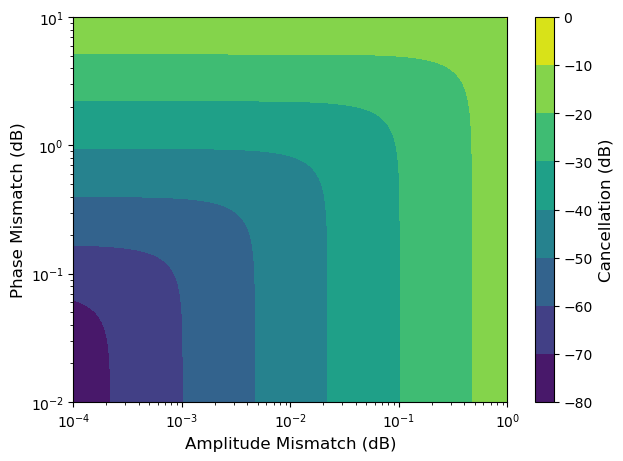

-75.08741353508873


In [18]:
fig,ax = plt.subplots(1,1, figsize=(7,5))
X, Y = np.meshgrid(t_amp_log, t_phs_log)
cp = ax.contourf(X, Y, t_001_db, cmap = 'viridis')
cbar = fig.colorbar(cp)
cbar.ax.set_ylabel('Cancellation (dB)',fontsize =fs)
# ax.set_title('Cancellation')
ax.set_xlabel('Amplitude Mismatch (dB)',fontsize =fs)
ax.set_ylabel('Phase Mismatch (dB)',fontsize =fs)
ax.set_yscale('log')
ax.set_xscale('log')
if isSaving:
    outputFile = 'CancellationContour.pdf'
    plt.savefig(outputFile, format='pdf', dpi=dpi_res, bbox_inches='tight')
plt.show()
print(np.min(t_001_db))


In [19]:
no_dp=500

t_amp_neg_log = np.logspace(-4,0, num=no_dp) #db
t_amp_pos_log = np.logspace(-4,0, num=no_dp) #db
t_amp_np_log = np.concatenate((t_amp_neg_log[::-1],t_amp_pos_log),axis=0)
t_amp_np_log_plotting = np.concatenate((-1*t_amp_neg_log[::-1],t_amp_pos_log),axis=0)

t_phs_neg_log = np.logspace(-2,1, num=no_dp) #db
t_phs_pos_log = np.logspace(-2,1, num=no_dp) #db
t_phs_np_log = np.concatenate((t_phs_neg_log[::-1],t_phs_pos_log),axis=0)
t_phs_np_log_plotting = np.concatenate((-1*t_phs_neg_log[::-1],t_phs_pos_log),axis=0)


t_amp2 = 10**(t_amp_np_log/10)

cancellation = np.zeros((int(2*no_dp),int(2*no_dp)))
for i in range(int(2*no_dp)):
    for j in range(int(2*no_dp)):
        cancellation[i,j] = 10*np.log10(1 + t_amp2[i]**2 - 2*t_amp2[i]*np.cos(t_phs_np_log[j]*np.pi/180))
        


X, Y = np.meshgrid(t_amp_np_log_plotting, t_phs_np_log_plotting)

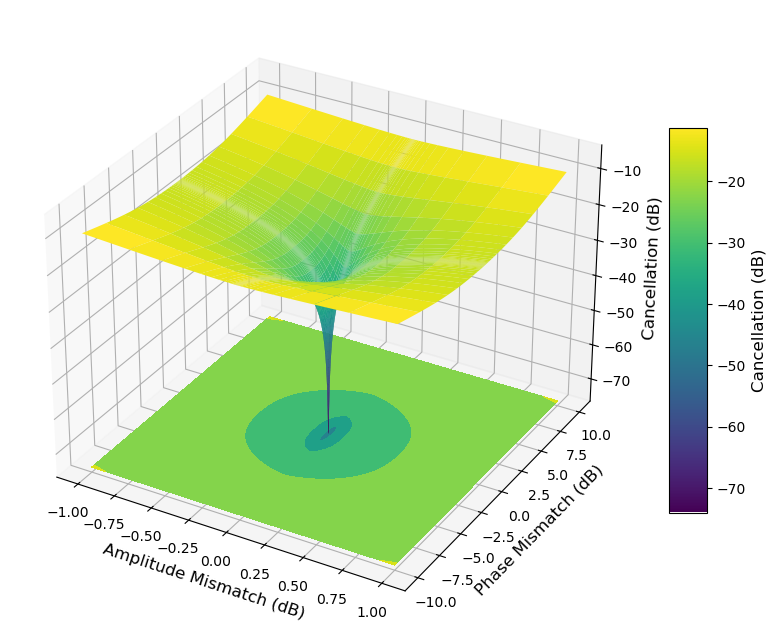

In [20]:
### Make it 3d
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10,10))
surf = ax.plot_surface(X, Y, cancellation, cmap='viridis',
                       linewidth=0.1, antialiased=True,edgecolor ='none')

cbar =fig.colorbar(surf, ax = ax,
             shrink = 0.5, aspect = 10)
cbar.ax.set_ylabel('Cancellation (dB)',fontsize =fs)
ax.set_xlabel('Amplitude Mismatch (dB)',fontsize =fs)
ax.set_ylabel('Phase Mismatch (dB)',fontsize =fs)
ax.set_zlabel('Cancellation (dB)',fontsize =fs)

cset = ax.contourf(X, Y, cancellation,
                   zdir ='z',
                   offset = np.min(cancellation),
                   cmap='viridis')

if isSaving:
    outputFile = 'CancellationSurface.pdf'
    plt.savefig(outputFile, format='pdf', dpi=dpi_res, bbox_inches='tight')

plt.show()

/var/folders/07/gr2d381s6qd7z37r9vj0qgl80008nl/T/ipykernel_3726/1776685324.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  orig_map=plt.cm.get_cmap('plasma')


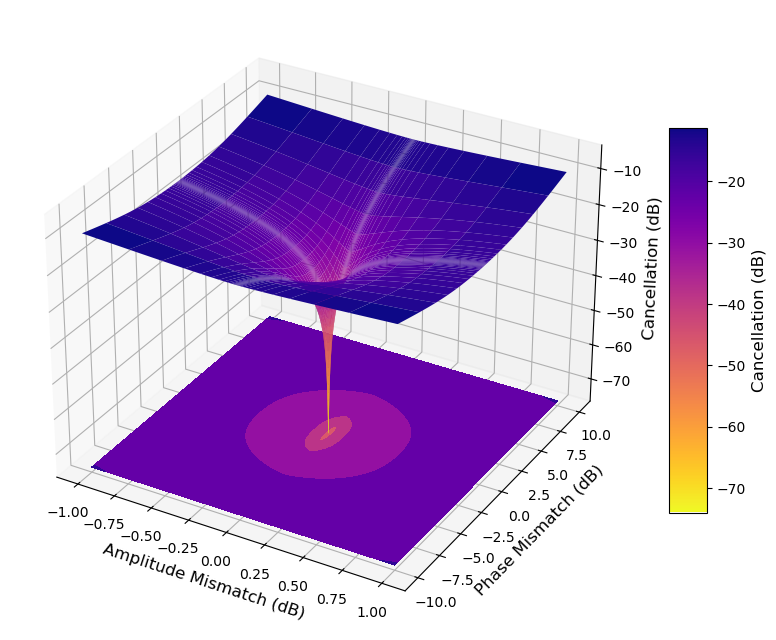

In [21]:
### Make it 3d
# getting the original colormap using cm.get_cmap() function
orig_map=plt.cm.get_cmap('plasma')
  
# reversing the original colormap using reversed() function
reversed_map = orig_map.reversed()


fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10,10))
surf = ax.plot_surface(X, Y, cancellation, cmap=reversed_map,
                       linewidth=0.1, antialiased=True,edgecolor ='none')

cbar =fig.colorbar(surf, ax = ax,
             shrink = 0.5, aspect = 10)
cbar.ax.set_ylabel('Cancellation (dB)',fontsize =fs)
ax.set_xlabel('Amplitude Mismatch (dB)',fontsize =fs)
ax.set_ylabel('Phase Mismatch (dB)',fontsize =fs)
ax.set_zlabel('Cancellation (dB)',fontsize =fs)

cset = ax.contourf(X, Y, cancellation,
                   zdir ='z',
                   offset = np.min(cancellation),
                   cmap=reversed_map)

# if isSaving:
#     outputFile = 'CancellationSurface.pdf'
#     plt.savefig(outputFile, format='pdf', dpi=dpi_res, bbox_inches='tight')

plt.show()